In [1]:
import numpy as np
import galsim
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
from astropy.table import Table

In [2]:
def plot_distribution(arr, title='placeholder title', bins=50, max_shapiro_n=5000, figsize=(8,4), show=True):
    """
    Gaussian check
    """
    try:
        a = np.asarray(arr, dtype=float).ravel()
    except Exception:
        cleaned = []
        for x in arr:
            if x is None:
                cleaned.append(np.nan); continue
            if hasattr(x, 'rad'):
                cleaned.append(getattr(x, 'rad'))
            elif hasattr(x, 'value'):
                cleaned.append(getattr(x, 'value'))
            else:
                try:
                    cleaned.append(float(x))
                except Exception:
                    cleaned.append(np.nan)
        a = np.asarray(cleaned, dtype=float)

    a = a[~np.isnan(a)]
    n = a.size
    if n == 0:
        raise ValueError("No numeric data after cleaning.")

    mu = float(a.mean())
    sigma = float(a.std(ddof=1)) if n > 1 else 0.0
    skew = float(stats.skew(a, bias=False))
    kurt = float(stats.kurtosis(a, fisher=False, bias=False))  # Pearson

    # grid
    span = (a.max() - a.min()) if (a.max() > a.min()) else 1.0
    x = np.linspace(a.min() - 0.2*span, a.max() + 0.2*span, 512)
    pdf_gauss = stats.norm.pdf(x, loc=mu, scale=max(sigma, 1e-16))

    # KDE: try usual, if it fails add tiny jitter, if still fails fallback to hist approximation
    pdf_kde = None
    try:
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=UserWarning)
            kde = stats.gaussian_kde(a)
            pdf_kde = kde(x)
    except Exception:
        # add jitter and retry
        try:
            jitter = 1e-12 * max(abs(mu), 1.0)
            kde = stats.gaussian_kde(a + jitter * np.random.randn(n))
            pdf_kde = kde(x)
        except Exception:
            pdf_kde = None

    # rmse between pdfs (kde preferred, else hist-based)
    if pdf_kde is not None:
        rmse_pdf = float(np.sqrt(np.mean((pdf_kde - pdf_gauss)**2)))
    else:
        hist_vals, edges = np.histogram(a, bins=bins, density=True)
        centers = 0.5*(edges[:-1] + edges[1:])
        g_centers = stats.norm.pdf(centers, loc=mu, scale=max(sigma, 1e-16))
        rmse_pdf = float(np.sqrt(np.mean((hist_vals - g_centers)**2)))

    # Shapiro: run only on subsample if n > max_shapiro_n
    shapiro_p = None
    try:
        if n > max_shapiro_n:
            idx = np.random.choice(n, size=max_shapiro_n, replace=False)
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore")
                sh = stats.shapiro(a[idx])
        else:
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore")
                sh = stats.shapiro(a)
        shapiro_p = float(sh.pvalue)
    except Exception:
        shapiro_p = None

    results = {
        'n': int(n),
        'mu': mu,
        'sigma': sigma,
        'skew': skew,
        'kurtosis': kurt,
        'rmse_pdf': rmse_pdf,
        'shapiro_p': shapiro_p
    }

    # Plotting
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle(title)
    ax0.hist(a, bins=bins, density=True, alpha=0.6, edgecolor='k')
    ax0.plot(x, pdf_gauss, '--', linewidth=1.3, label=f'Gaussian fit\nμ={mu:.3g}, σ={sigma:.3g}')
    if pdf_kde is not None:
        ax0.plot(x, pdf_kde, linewidth=1.1, label='KDE')
    ax0.set_xlabel('Value'); ax0.set_ylabel('Density'); ax0.legend(); ax0.set_title('Histogram + Gaussian')

    # Q-Q plot (guard against sigma==0)
    try:
        if sigma <= 0:
            ax1.text(0.5,0.5,"All values identical (sigma=0)", ha='center', va='center')
        else:
            stats.probplot(a, dist="norm", sparams=(mu, sigma), plot=ax1)
            ax1.set_title('Q–Q plot vs fitted normal')
    except Exception:
        ax1.text(0.5,0.5,"Q–Q failed", ha='center', va='center')

    plt.tight_layout()
    if show:
        plt.show()

    return fig, results

In [3]:
cosmos_cat_fname = "../cosmos15_superbit2023_phot_shapes_with_sigma.csv"
cosmos_cat = Table.read(cosmos_cat_fname, format="csv")

In [4]:
q   = cosmos_cat['c10_sersic_fit_q'] # grab q vals
q = np.where(q > 1, 1/q, q) # invert entry in q vals if its >1
phi = cosmos_cat['c10_sersic_fit_phi'] * galsim.radians # grab phis and convert to angles
phi_array = np.array([p.rad for p in phi]) # this array is for plotting, it switches the away from Object
hlr = cosmos_cat['c10_sersic_fit_hlr']*0.03*np.sqrt(q) # grabs hlr and converts to arcsecs
hlr_cleaned = hlr[(hlr > np.percentile(hlr, 1)) & (hlr < np.percentile(hlr, 99))] # this step is done in my code so I did it here
hlr_log = np.log(hlr_cleaned) # this is to see the gaussian distr (uses cleaned to avoid logging a zero value)

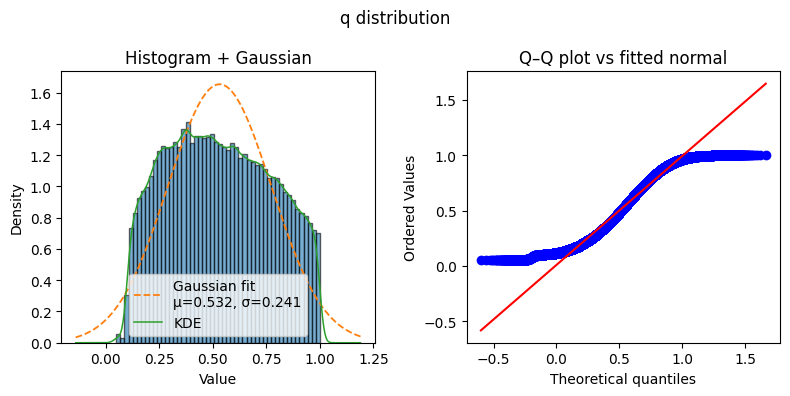

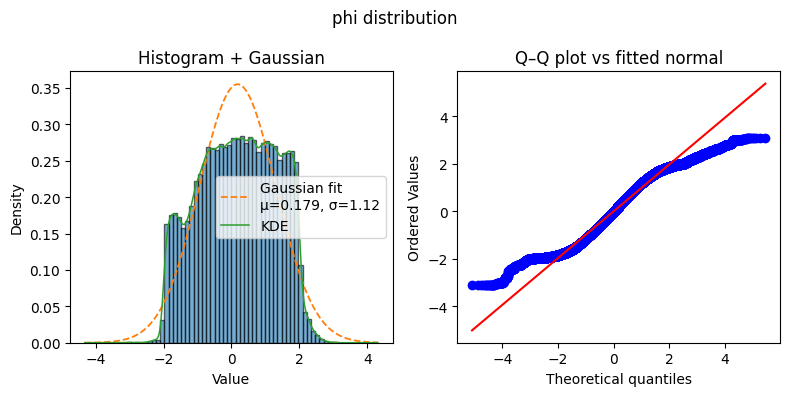

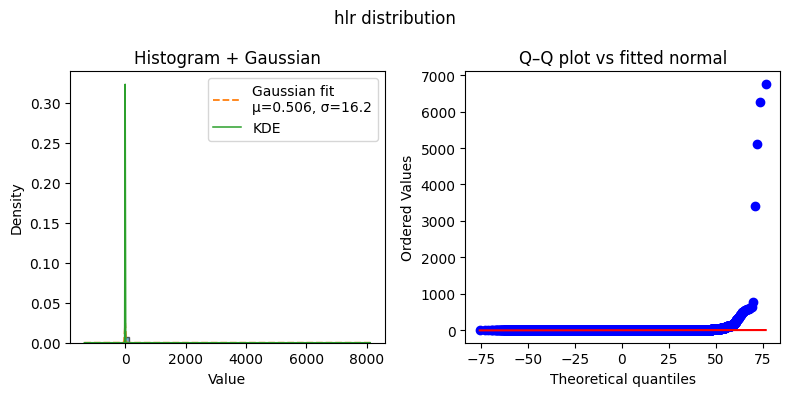

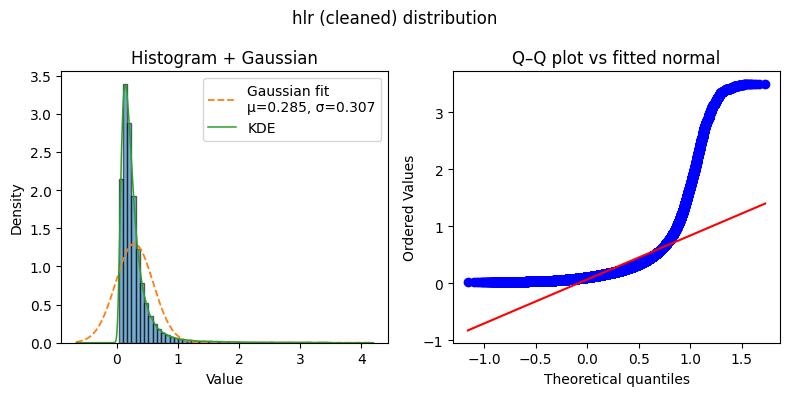

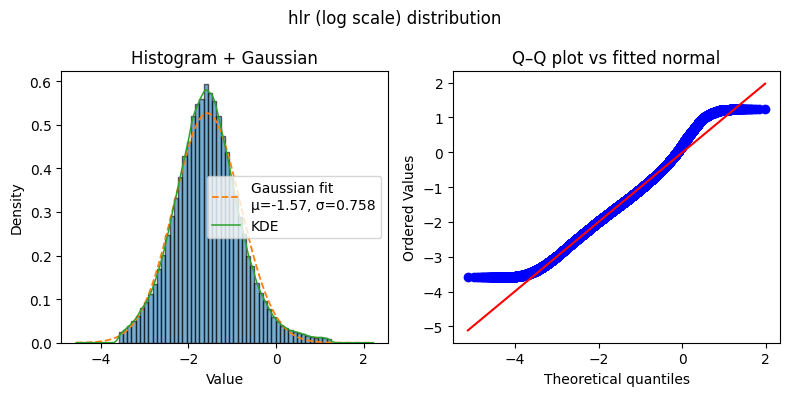

In [5]:
# Plot a histrogram with a gaussian fit along with a Q-Q plot (Q-Q is basically how similar the distributions are)

plot_distribution(arr=q, title='q distribution')
plot_distribution(arr=phi_array, title='phi distribution')
plot_distribution(arr=hlr, title='hlr distribution')
plot_distribution(arr=hlr_cleaned, title='hlr (cleaned) distribution')
plot_distribution(arr=hlr_log, title='hlr (log scale) distribution');

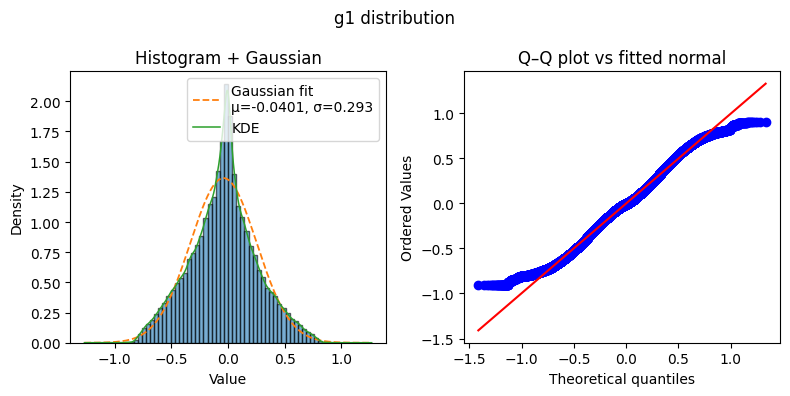

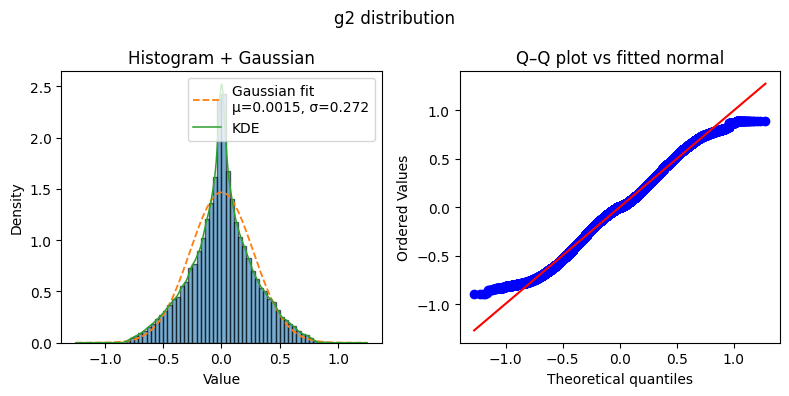

In [6]:
# Visualize g1 g2 distributions from catalog

shears = [galsim.Shear(q=float(q), beta=b) for q, b in zip(q, phi)]
g1 = np.array([s.g1 for s in shears])
g2 = np.array([s.g2 for s in shears])
plot_distribution(arr=g1, title='g1 distribution')
plot_distribution(arr=g2, title='g2 distribution');

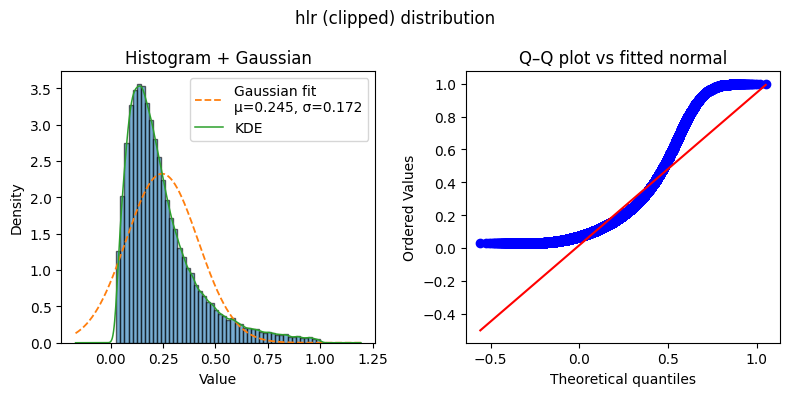

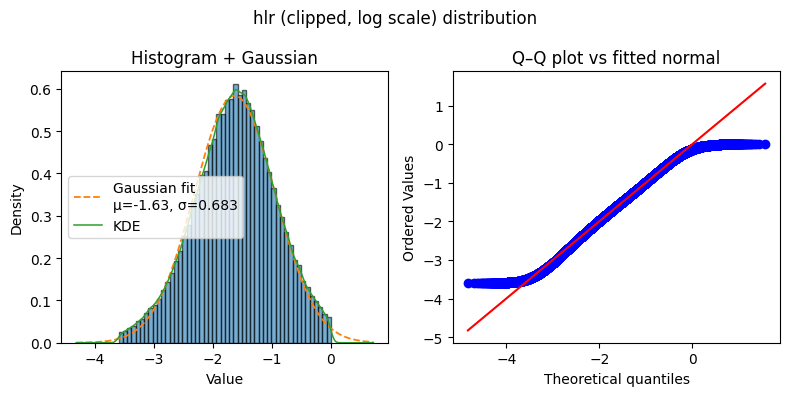

In [7]:
# Clip hlr to 1 arcsec (uses cleaned hlr array due to previous results)

hlr_clipped = hlr_cleaned[hlr_cleaned <= 1]
hlr_clipped_log = np.log(hlr_clipped)

plot_distribution(arr=hlr_clipped, title='hlr (clipped) distribution')
plot_distribution(arr=hlr_clipped_log, title='hlr (clipped, log scale) distribution');